In [1]:
import numpy as np 
import pandas as pd

In [2]:
import seaborn as sb
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("datasets\minute maid_from_dump.csv")
df

,code,product_name,brands,categories_tags,countries_tags,packaging_tags,stores,purchase_places,nutriscore_grade,nova_group,ecoscore_grade,ingredients_text,nutriments.sugars_100g,nutriments.energy-kcal_100g
0,0025000034824,"Minute maid, sparkling juice drink, fruit punch",Minute Maid,"plant-based-foods-and-beverages, beverages, pl...","france, united-states",NaN,NaN,NaN,c,4.0,NaN,"Carbonated water, grape and apple juices from ...",NaN,NaN
1,0025000047244,Fruit Cooler Lemonade,Minute Maid,"beverages, carbonated-drinks, sodas, lemonade",france,NaN,NaN,NaN,e,NaN,NaN,NaN,NaN,NaN
2,0025000056017,100% Apple Juice,Minute Maid,"plant-based-foods-and-beverages, beverages, pl...",united-states,NaN,NaN,NaN,unknown,NaN,c,NaN,NaN,NaN
3,0025000056031,100% Orange Juice,Minute Maid,"beverages-and-beverages-preparations, plant-ba...",united-states,NaN,NaN,California,e,1.0,a,"pure filtered water, concentrated orange juice...",10.0,48.9
4,0025000058073,Lemonade,Minute Maid,"beverages-and-beverages-preparations, beverage...",france,NaN,NaN,NaN,e,4.0,NaN,"Pure filtered water, high fructose corn syrup,...",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
680,01070965,Minute maid,NaN,NaN,france,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN
681,6975682483042,MZY Peach Juice Drink,"Minute Maid, Coca-Cola, MZY","beverages-and-beverages-preparations, plant-ba...","china, united-kingdom",NaN,NaN,NaN,e,4.0,NaN,"Water, fructose syrup, sugar, concentrated pea...",NaN,NaN
682,9416216001433,Minute Maid Pulpy,Orange,NaN,fiji,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN
683,4902102060646,Apple 100%,Minute Maid,NaN,united-states,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN


In [5]:
df.columns

Index(['code', 'product_name', 'brands', 'categories_tags', 'countries_tags',
       'packaging_tags', 'stores', 'purchase_places', 'nutriscore_grade',
       'nova_group', 'ecoscore_grade', 'ingredients_text',
       'nutriments.sugars_100g', 'nutriments.energy-kcal_100g'],
      dtype='object')

In [6]:
df.dtypes

code                            object
product_name                    object
brands                          object
categories_tags                 object
countries_tags                  object
packaging_tags                  object
stores                          object
purchase_places                 object
nutriscore_grade                object
nova_group                     float64
ecoscore_grade                  object
ingredients_text                object
nutriments.sugars_100g         float64
nutriments.energy-kcal_100g    float64
dtype: object

In [7]:
df.code[df.duplicated()]

Series([], Name: code, dtype: object)

In [8]:
df.isnull().sum()

code                             0
product_name                    10
brands                          51
categories_tags                256
countries_tags                   0
packaging_tags                 618
stores                         659
purchase_places                646
nutriscore_grade                 0
nova_group                     498
ecoscore_grade                 542
ingredients_text               294
nutriments.sugars_100g         344
nutriments.energy-kcal_100g    341
dtype: int64

In [9]:
df.product_name = df.product_name.fillna('unknown')
df.brands = df.brands.fillna('unknown')
df.categories_tags = df.categories_tags.fillna('unknown')
df.packaging_tags = df.packaging_tags.fillna('unknown')
df.stores = df.stores.fillna('unknown')
df.purchase_places = df.purchase_places.fillna('unknown')
df.ecoscore_grade = df.ecoscore_grade.fillna('unknown')
df.ingredients_text = df.ingredients_text.fillna('unknown')


In [10]:
df.isnull().sum()

code                             0
product_name                     0
brands                           0
categories_tags                  0
countries_tags                   0
packaging_tags                   0
stores                           0
purchase_places                  0
nutriscore_grade                 0
nova_group                     498
ecoscore_grade                   0
ingredients_text                 0
nutriments.sugars_100g         344
nutriments.energy-kcal_100g    341
dtype: int64

# Extracting Countries
1) United States dominates with approximately 360 products, making it the largest contributor by a significant margin.
2) France ranks second with around 150 products, but its contribution is less than half of the United States.
3) Canada (~70) and Belgium (~30) are the next major contributors, showing a much smaller representation compared with the top two countries.
4) Countries such as Spain, India, Ireland, and Germany each contribute only around 8–15 products, indicating relatively low representation in the dataset.

In [11]:
df.countries_tags.unique()

array(['france, united-states', 'france', 'united-states',
       'saint-pierre-and-miquelon', 'canada, france', 'canada',
       'france, martinique, switzerland', 'belgium, france, luxembourg',
       'taiwan', 'hong-kong', 'belgium, france', 'belgium',
       'belgium, france, martinique, switzerland', 'france, spain',
       'belgium, france, world', 'united-kingdom', 'spain', 'thailand',
       'india', 'france, luxembourg', 'belgium, france, germany',
       'belgium, france, switzerland', 'belgium, france, reunion',
       'france, spain, united-states', 'canada, switzerland',
       'martinique', 'switzerland', 'france, world', 'germany',
       'belgium, world', 'singapore', 'france, united-states, world',
       'senegal', 'united-states, world', 'mexico', 'canada, germany',
       'ireland', 'aruba', 'puerto-rico', 'luxembourg', 'kenya',
       'jamaica', 'philippines', 'barbados', 'ethiopia', 'suriname',
       'malaysia', 'mayotte', 'trinidad-and-tobago', 'norway', 'japan'

In [12]:
df.countries_tags.value_counts

<bound method IndexOpsMixin.value_counts of 0      france, united-states
1                     france
2              united-states
3              united-states
4                     france
               ...          
680                   france
681    china, united-kingdom
682                     fiji
683            united-states
684                    japan
Name: countries_tags, Length: 685, dtype: object>

In [13]:
raw_countries = df.countries_tags.str.split(',')
raw_countries

0      [france,  united-states]
1                      [france]
2               [united-states]
3               [united-states]
4                      [france]
                 ...           
680                    [france]
681    [china,  united-kingdom]
682                      [fiji]
683             [united-states]
684                     [japan]
Name: countries_tags, Length: 685, dtype: object

In [14]:
exploded_countries = raw_countries.explode()
exploded_countries

0               france
0        united-states
1               france
2        united-states
3        united-states
            ...       
681              china
681     united-kingdom
682               fiji
683      united-states
684              japan
Name: countries_tags, Length: 757, dtype: object

In [15]:
exploded_countries = exploded_countries.str.strip()
exploded_countries

0              france
0       united-states
1              france
2       united-states
3       united-states
            ...      
681             china
681    united-kingdom
682              fiji
683     united-states
684             japan
Name: countries_tags, Length: 757, dtype: object

In [16]:
exploded_countries.value_counts()

countries_tags
united-states                          360
france                                 152
canada                                  68
belgium                                 31
world                                   16
philippines                             16
spain                                   13
india                                   13
ireland                                 11
germany                                  8
thailand                                 7
japan                                    7
luxembourg                               5
switzerland                              5
martinique                               4
netherlands                              4
singapore                                4
hong-kong                                3
united-kingdom                           3
malaysia                                 2
china                                    2
kenya                                    2
saint-pierre-and-miquelon              

In [17]:
exploded_countries.value_counts().sum()

np.int64(757)

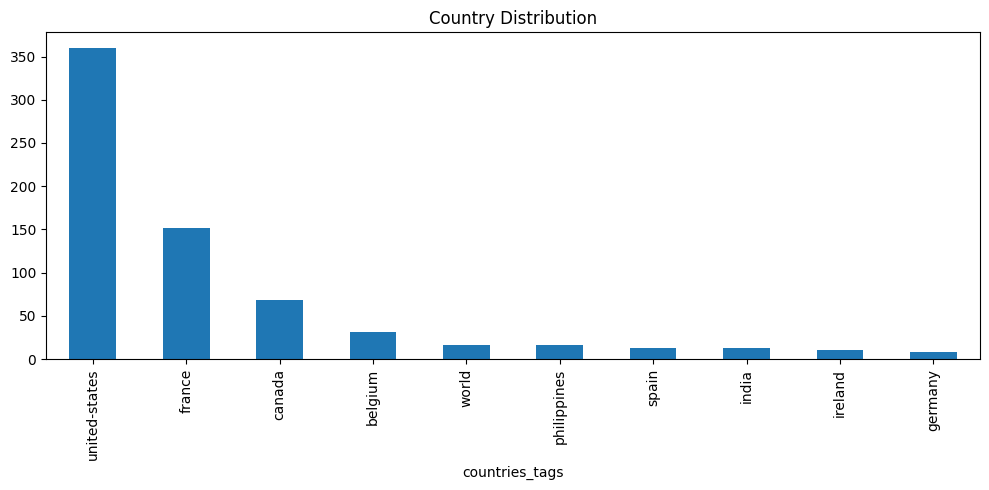

In [18]:
plt.figure(figsize=(10,5))

exploded_countries.value_counts().head(10).plot(kind='bar')

plt.title("Country Distribution")
plt.tight_layout()
plt.show()

# Extracting Packaging
1) Bottles are the most common packaging type, with approximately 18 products.
2) Cans (14) are the second most common, followed by drink-cans and plastic packaging (12 each).
3) Tetra Pak (6), brick (5), and cardboard (5) have moderate representation in the dataset.
4) Metal (4), Tetra-brik aseptic (4), and multilayer composite (3) are the least common packaging types, indicating relatively lower usage.

In [19]:
df.packaging_tags.unique()

array(['unknown', 'pet-bottle', 'brick', 'cardboard', 'plastic',
       'box, card, pasteurized', 'can, drink-can', 'cardboard, tumbler',
       'bouteille-verre', 'tetra-pak, tetra-brik-aseptic',
       'plastic, bottle', 'bottle', 'tetra-brik', 'metal, can, drink-can',
       'brick, cardboard', 'can', 'brique',
       'metal, recyclable-metals, aluminium, can, drink-can',
       'glass, bottle, bouteille-consignee', 'th:ขวด, th:ขวดพลาสติก',
       'plastic, bottle, plastic-bottle', 'glass, bottle',
       'bouteille-en-verre', 'tetra-pak, brick, gold-bricks', 'conserve',
       'bottle-or-vial, bottle',
       'multilayer-composite, tetra-pak, tetra-brik-aseptic',
       'plastic-bottle', 'tetra-pac', 'container',
       'metal, recyclable-metals, aluminium',
       '1-canette-en-metal-a-recycler', 'tetra-pak', 'paper-based-carton',
       'orange', 'plastic, cardboard'], dtype=object)

In [20]:
raw_packaging = df.packaging_tags.str.split(',')
raw_packaging

0      [unknown]
1      [unknown]
2      [unknown]
3      [unknown]
4      [unknown]
         ...    
680    [unknown]
681    [unknown]
682    [unknown]
683    [unknown]
684    [unknown]
Name: packaging_tags, Length: 685, dtype: object

In [21]:
exploded_packaging = raw_packaging.explode()
exploded_packaging = exploded_packaging.str.strip()
exploded_packaging

0      unknown
1      unknown
2      unknown
3      unknown
4      unknown
        ...   
680    unknown
681    unknown
682    unknown
683    unknown
684    unknown
Name: packaging_tags, Length: 731, dtype: object

In [22]:
exploded_packaging.value_counts()

packaging_tags
unknown                          618
bottle                            18
can                               14
drink-can                         12
plastic                           12
tetra-pak                          6
brick                              5
cardboard                          5
metal                              4
tetra-brik-aseptic                 4
multilayer-composite               3
pet-bottle                         2
recyclable-metals                  2
aluminium                          2
tetra-brik                         2
glass                              2
plastic-bottle                     2
box                                1
card                               1
brique                             1
bouteille-verre                    1
pasteurized                        1
tumbler                            1
th:ขวด                             1
th:ขวดพลาสติก                      1
bouteille-en-verre                 1
bouteille-consignee    

In [23]:
exploded_packaging.value_counts().sum()

np.int64(731)

In [24]:
exploded_packaging = exploded_packaging[exploded_packaging != "unknown"]
exploded_packaging.value_counts()

packaging_tags
bottle                           18
can                              14
drink-can                        12
plastic                          12
tetra-pak                         6
brick                             5
cardboard                         5
metal                             4
tetra-brik-aseptic                4
multilayer-composite              3
pet-bottle                        2
recyclable-metals                 2
aluminium                         2
tetra-brik                        2
glass                             2
plastic-bottle                    2
box                               1
card                              1
brique                            1
bouteille-verre                   1
pasteurized                       1
tumbler                           1
th:ขวด                            1
th:ขวดพลาสติก                     1
bouteille-en-verre                1
bouteille-consignee               1
gold-bricks                       1
conserve     

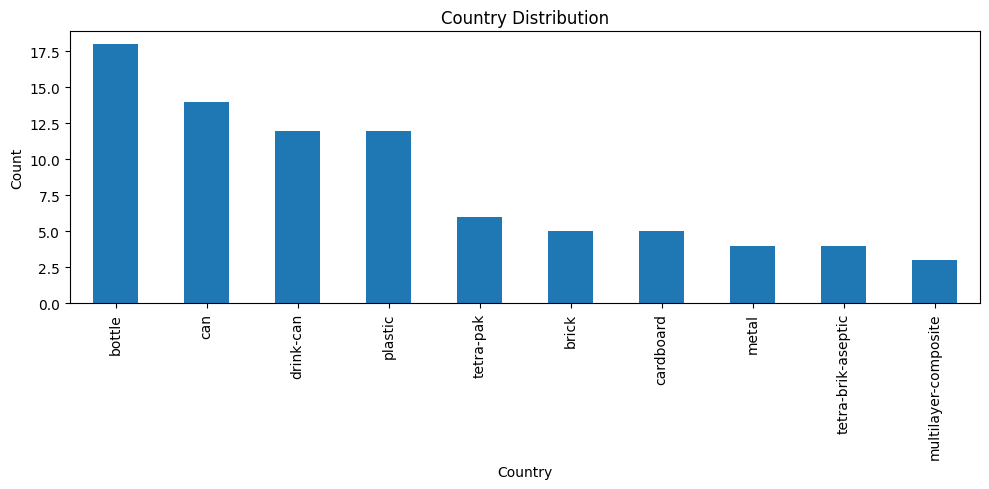

In [25]:
plt.figure(figsize=(10,5))

exploded_packaging.value_counts().head(10).plot(kind='bar')

plt.title("Country Distribution")
plt.ylabel("Count")
plt.xlabel("Country")
plt.tight_layout()
plt.show()

In [26]:
df.columns

Index(['code', 'product_name', 'brands', 'categories_tags', 'countries_tags',
       'packaging_tags', 'stores', 'purchase_places', 'nutriscore_grade',
       'nova_group', 'ecoscore_grade', 'ingredients_text',
       'nutriments.sugars_100g', 'nutriments.energy-kcal_100g'],
      dtype='object')

# Extracting Nutriscore
1) Grade E is the most common, with approximately 144 products, indicating a large share of products with poor nutritional quality.
2) Grade B ranks second at around 102 products, showing a substantial number of relatively healthier products.
3) Grade C has about 83 products, placing it between the healthier B grade and poorer E grade.
4) Grade D is the least common, with approximately 40 products. Overall, E-grade products dominate the dataset, suggesting that many products have lower nutritional quality.

In [27]:
df.nutriscore_grade.unique()

array(['c', 'e', 'unknown', 'd', 'b'], dtype=object)

In [28]:
df.nutriscore_grade.value_counts()

nutriscore_grade
unknown    316
e          144
b          102
c           83
d           40
Name: count, dtype: int64

In [29]:
raw_nutriscore = df.nutriscore_grade.value_counts()
raw_nutriscore

nutriscore_grade
unknown    316
e          144
b          102
c           83
d           40
Name: count, dtype: int64

In [30]:
raw_nutriscore = raw_nutriscore.drop("unknown")
raw_nutriscore

nutriscore_grade
e    144
b    102
c     83
d     40
Name: count, dtype: int64

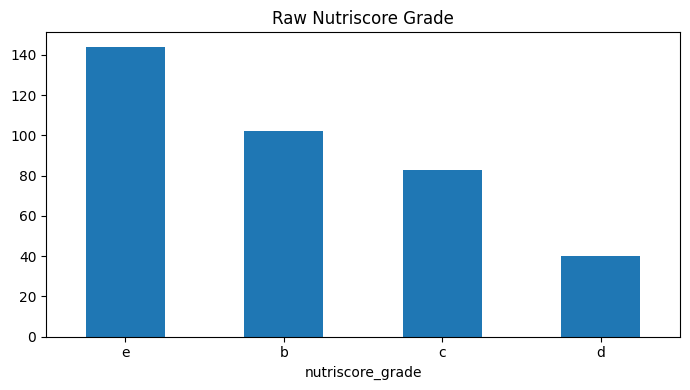

In [31]:
plt.figure(figsize=(7,4))

raw_nutriscore.plot(kind='bar')

plt.title("Raw Nutriscore Grade")
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

In [32]:
df.columns

Index(['code', 'product_name', 'brands', 'categories_tags', 'countries_tags',
       'packaging_tags', 'stores', 'purchase_places', 'nutriscore_grade',
       'nova_group', 'ecoscore_grade', 'ingredients_text',
       'nutriments.sugars_100g', 'nutriments.energy-kcal_100g'],
      dtype='object')

# Extracting Nova Group
1) 133 is the largest group, representing the highest number of products.
2) 50 is the second-largest group, with considerably fewer products than the first.
3) 4 is very small, indicating limited representation of that group.
The chart should ideally show the Nova Group names on the X-axis and their counts on the Y-axis.

In [33]:
df.nova_group.unique()

array([ 4., nan,  1.,  3.])

In [34]:
df.nova_group.value_counts()
raw_nova = df.nova_group.value_counts()
raw_nova

nova_group
4.0    133
1.0     50
3.0      4
Name: count, dtype: int64

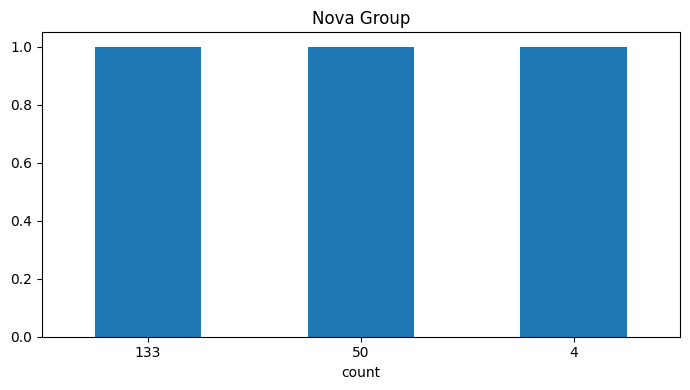

In [35]:
plt.figure(figsize=(7,4))

raw_nova.value_counts().plot(kind='bar')

plt.title("Nova Group")
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

# Country wise observation 
I handled the France, Belgium, Spain datasets. Spain contained significant null/unknown values, limiting further analysis. USA and Canada were processed by teammate Aditya, while the Philippines dataset was excluded due to insufficient reliable data.

In [43]:
exploded_countries.value_counts()

countries_tags
united-states                          360
france                                 152
canada                                  68
belgium                                 31
world                                   16
philippines                             16
spain                                   13
india                                   13
ireland                                 11
germany                                  8
thailand                                 7
japan                                    7
luxembourg                               5
switzerland                              5
martinique                               4
netherlands                              4
singapore                                4
hong-kong                                3
united-kingdom                           3
malaysia                                 2
china                                    2
kenya                                    2
saint-pierre-and-miquelon              

# FRANCE 


In [44]:
france = df[df['countries_tags'].str.contains("france")]
france

,code,product_name,brands,categories_tags,countries_tags,packaging_tags,stores,purchase_places,nutriscore_grade,nova_group,ecoscore_grade,ingredients_text,nutriments.sugars_100g,nutriments.energy-kcal_100g
0,0025000034824,"Minute maid, sparkling juice drink, fruit punch",Minute Maid,"plant-based-foods-and-beverages, beverages, pl...","france, united-states",unknown,unknown,unknown,c,4.0,unknown,"Carbonated water, grape and apple juices from ...",NaN,NaN
1,0025000047244,Fruit Cooler Lemonade,Minute Maid,"beverages, carbonated-drinks, sodas, lemonade",france,unknown,unknown,unknown,e,NaN,unknown,unknown,NaN,NaN
4,0025000058073,Lemonade,Minute Maid,"beverages-and-beverages-preparations, beverage...",france,unknown,unknown,unknown,e,4.0,unknown,"Pure filtered water, high fructose corn syrup,...",NaN,NaN
5,0025000061516,100% apple juice,Minute Maid,"plant-based-foods-and-beverages, beverages, pl...","france, united-states",unknown,unknown,unknown,e,NaN,unknown,"CONTAINS PURE FILTERED WATER, CONCENTRATED APP...",NaN,NaN
9,0059600060594,Minute Maid Orange,Minute Maid,"plant-based-foods-and-beverages, beverages, pl...",france,unknown,unknown,unknown,unknown,NaN,unknown,unknown,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
654,5449000340023,Jus d'orange Minute Maid,Minute maid,"beverages-and-beverages-preparations, plant-ba...",france,unknown,unknown,unknown,e,NaN,unknown,Jus d'orange à base de concentré (55%) ; eau ;...,NaN,NaN
655,54032491,unknown,Minute Maid,"beverages-and-beverages-preparations, plant-ba...",france,unknown,unknown,unknown,unknown,NaN,unknown,unknown,NaN,NaN
660,5449000341112,minute maid orange nectar vit c,minute maid,unknown,france,unknown,unknown,unknown,unknown,NaN,unknown,unknown,NaN,NaN
666,5449000340108,pack 6x 20cl minute maid orange,minute maid,unknown,france,unknown,unknown,unknown,unknown,NaN,unknown,unknown,NaN,NaN


In [45]:
sfrance = france.copy()

In [46]:
sfrance.shape

(152, 14)

In [47]:
sfrance['nutriments.sugars_100g'].describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: nutriments.sugars_100g, dtype: float64

In [48]:
sfrance['nutriments.sugars_100g'].shape

(152,)

In [49]:
sfrance['nutriments.sugars_100g'].isnull().sum()

np.int64(152)

In [50]:
sfrance['nutriments.energy-kcal_100g'].shape

(152,)

In [51]:
sfrance['nutriments.sugars_100g'].isnull().sum()

np.int64(152)

In [52]:
pfrance = france.copy()

# Packaging of France
1) Cans are the most common packaging — can appears 13 times (18.3%), followed by drink-can with 12 times (16.9%). Together, cans account for 25 records (35.2%).
2) Bottles are also significant — bottle appears 8 times (11.3%), making it the third most common packaging type in the dataset.
3) Plastic packaging represents 8.5% — plastic appears 6 times (8.5%), while metal appears 4 times (5.6%). Combined, these two materials account for 10 records (14.1%).
4) Cardboard and brick packaging have moderate usage — both cardboard and brick appear 4 times each (5.6% each). tetra-pak appears 3 times (4.2%), showing notable use of carton-based packaging.
5) Packaging diversity is high — the dataset contains 22 different packaging tags, but the top 5 categories (can, drink-can, bottle, plastic, metal) account for 43 records (60.6%). This indicates that packaging is concentrated in a few major types, while the remaining 40.8% is spread across many less-common formats.

In [53]:
pfrance = pfrance[pfrance.packaging_tags != 'unknown']
pfrance.packaging_tags.value_counts()

packaging_tags
can, drink-can                                         9
plastic                                                3
plastic, bottle                                        3
bottle                                                 3
brick, cardboard                                       2
metal, can, drink-can                                  2
tetra-brik                                             2
tetra-pak, tetra-brik-aseptic                          1
bouteille-verre                                        1
cardboard, tumbler                                     1
cardboard                                              1
brick                                                  1
brique                                                 1
metal, recyclable-metals, aluminium, can, drink-can    1
can                                                    1
glass, bottle, bouteille-consignee                     1
glass, bottle                                          1
bouteille-en-ver

In [54]:
pfrance['packaging_tags'] = pfrance['packaging_tags'].str.split(',') 
pfrance = pfrance.explode("packaging_tags")
pfrance['packaging_tags'] = pfrance['packaging_tags'].str.strip() #remove starting void space
pfrance.packaging_tags.value_counts()


packaging_tags
can                              13
drink-can                        12
bottle                            8
plastic                           6
metal                             4
cardboard                         4
brick                             4
tetra-pak                         3
glass                             2
tetra-brik-aseptic                2
tetra-brik                        2
aluminium                         2
recyclable-metals                 2
tumbler                           1
bouteille-verre                   1
brique                            1
bouteille-consignee               1
bouteille-en-verre                1
gold-bricks                       1
conserve                          1
multilayer-composite              1
1-canette-en-metal-a-recycler     1
Name: count, dtype: int64

# We can mix Same material, different language or Same concept, different specificity
1) bottle + bouteille-verre + bouteille-consignee + bouteille-en-verre → these are French for "bottle" variants
2) brick + brique (French for brick)
3) can + 1-canette-en-metal-a-recycler (French: "1 metal can to recycle")
4) can + drink-can → both are cans
5) metal + aluminium + recyclable-metals → all metal
6) tetra-pak + tetra-brik + tetra-brik-aseptic → all Tetra Pak cartons
7) glass + bouteille-verre + bouteille-en-verre (glass bottles)

In [55]:
tag_mapping = {
    # can
    'drink-can': 'can',
    '1-canette-en-metal-a-recycler': 'can',
    'conserve': 'can',

    # bottle
    'bouteille-verre': 'bottle',
    'bouteille-consignee': 'bottle',
    'bouteille-en-verre': 'bottle',

    # brick
    'brique': 'brick',

    # metal
    'aluminium': 'metal',
    'recyclable-metals': 'metal',

    # tetra-pak
    'tetra-brik': 'tetra-pak',
    'tetra-brik-aseptic': 'tetra-pak',
}

pfrance['packaging_tags'] = pfrance['packaging_tags'].replace(tag_mapping)

pfrance.packaging_tags.value_counts()


packaging_tags
can                     27
bottle                  11
metal                    8
tetra-pak                7
plastic                  6
brick                    5
cardboard                4
glass                    2
tumbler                  1
gold-bricks              1
multilayer-composite     1
Name: count, dtype: int64

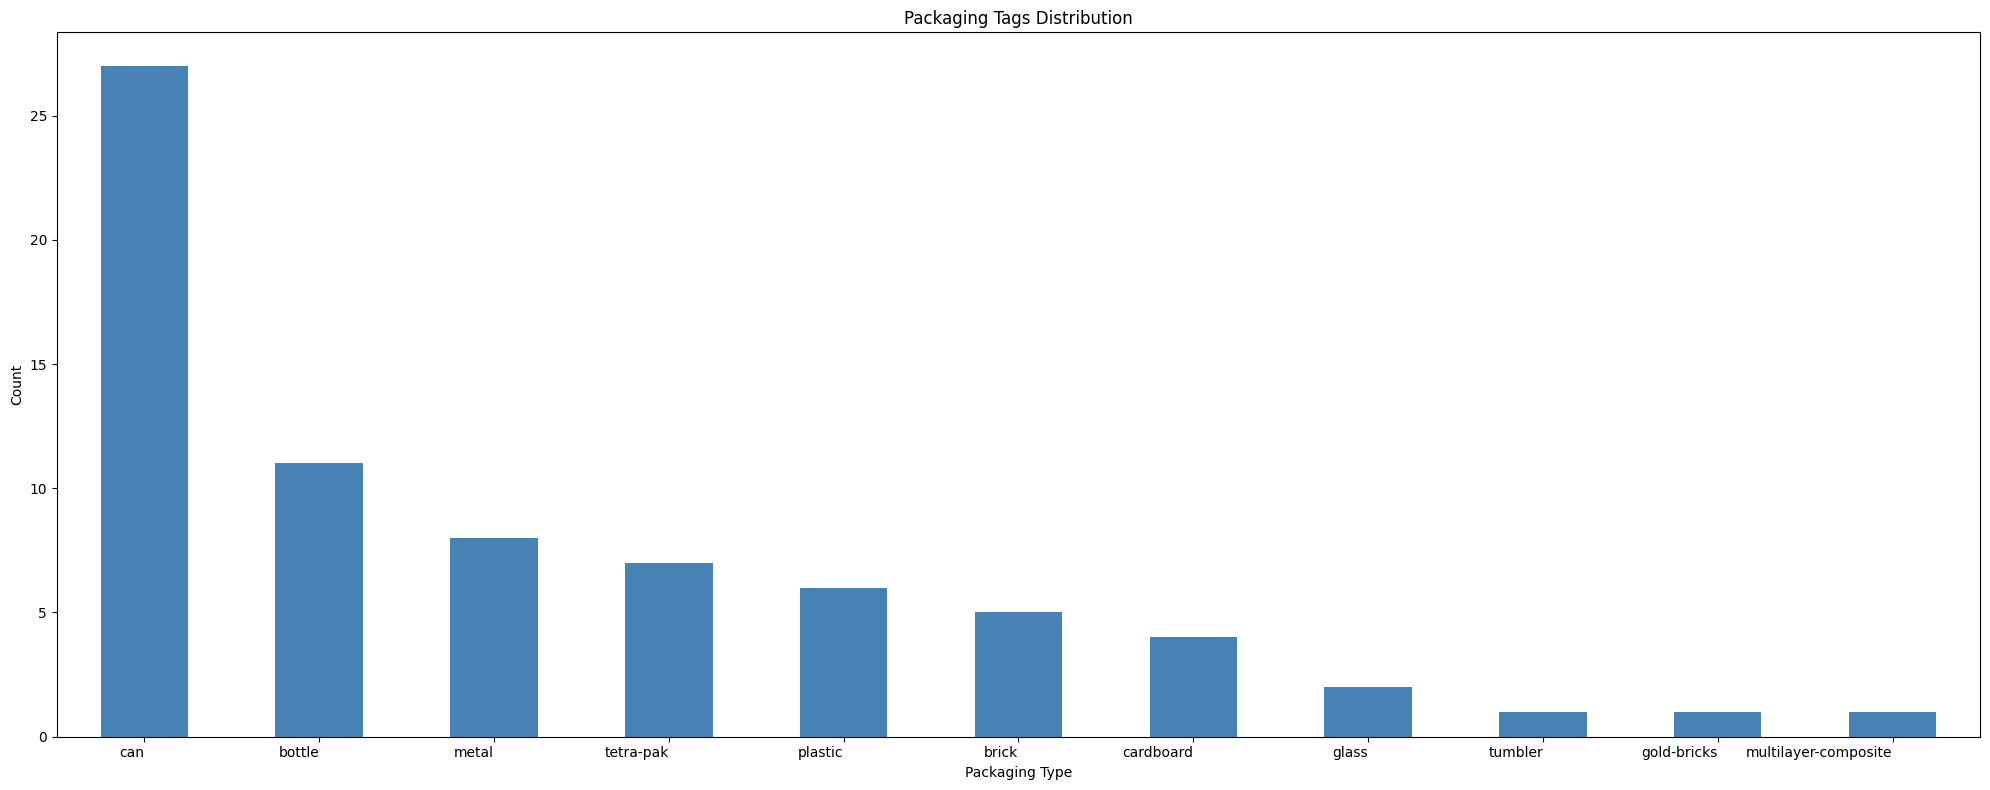

In [56]:
pcounts = pfrance.packaging_tags.value_counts()

plt.figure(figsize=(20, 8))
pcounts.plot(kind='bar', color='steelblue')
plt.title('Packaging Tags Distribution')
plt.xlabel('Packaging Type')
plt.ylabel('Count')
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

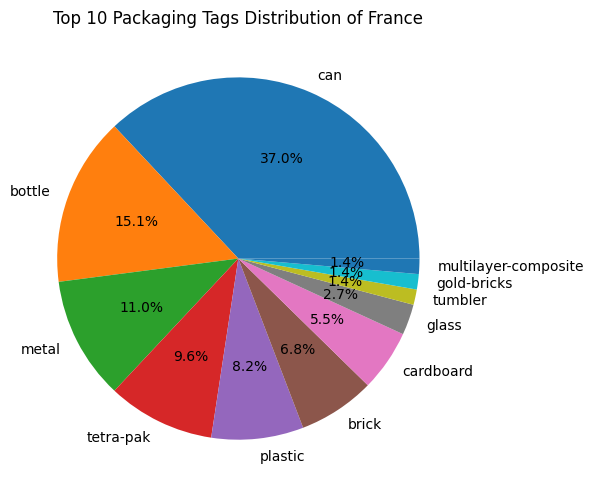

In [57]:
plt.figure(figsize=(6, 6))
pcounts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Top 10 Packaging Tags Distribution of France')
plt.ylabel('')
plt.tight_layout()
plt.show()

# Nutriscore Grade of France
1) Grade E dominates the dataset — 41 out of 91 products (45.1%) have a Nutri-Score E, indicating that nearly half of the analyzed products fall into the lowest nutritional grade.
2) Grade C is the second-largest category — 28 products (30.8%) received a Nutri-Score C, meaning almost one-third of the products have an intermediate nutritional quality.
3) Few products have better scores — only 4 products (4.4%) received Grade B, while no products received Grade A. Meanwhile, Grades D and E together account for 59 products (64.9%), showing that nearly two-thirds of the products have lower nutritional scores.

In [58]:
nfrance = france.copy()

In [59]:
nfrance.nutriscore_grade.value_counts()

nutriscore_grade
unknown    61
e          41
c          28
d          18
b           4
Name: count, dtype: int64

In [60]:
nfrance = nfrance[nfrance.nutriscore_grade != 'unknown']
nfrance.nutriscore_grade.value_counts()

nutriscore_grade
e    41
c    28
d    18
b     4
Name: count, dtype: int64

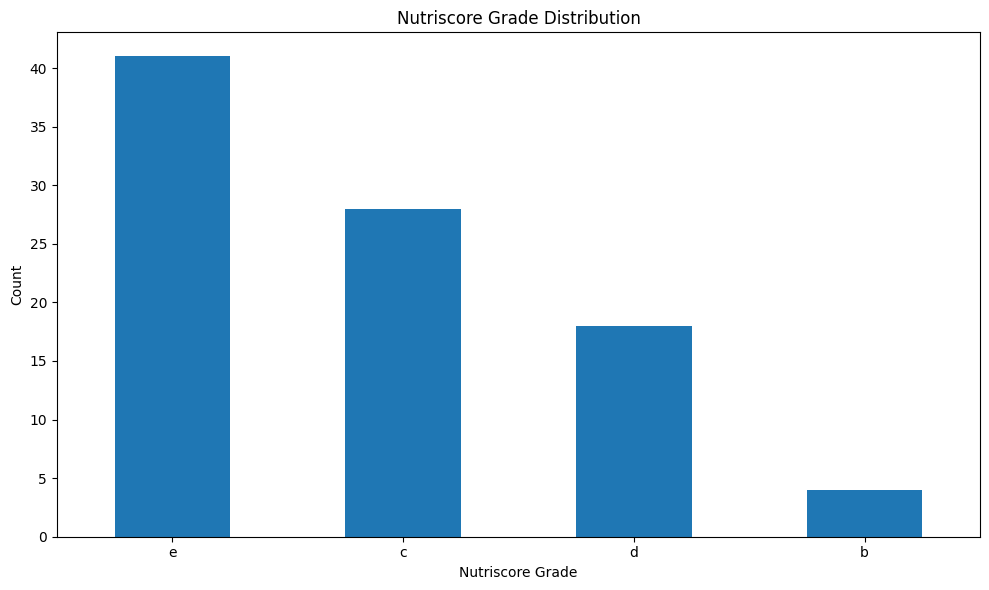

In [61]:
ncounts = nfrance.nutriscore_grade.value_counts()

plt.figure(figsize=(10, 6))
ncounts.plot(kind='bar')
plt.title('Nutriscore Grade Distribution')
plt.xlabel('Nutriscore Grade')
plt.ylabel('Count')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()


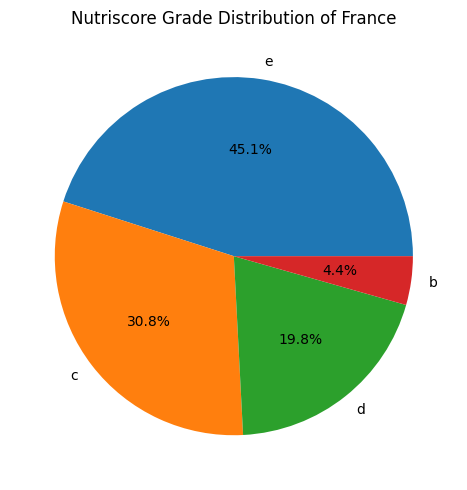

In [62]:
plt.figure(figsize=(5,5))
ncounts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Nutriscore Grade Distribution of France')
plt.ylabel('')
plt.tight_layout()
plt.show()

# Nova Group of France 

1) Ultra-processed foods dominate — 36 out of 65 products (55.4%) are NOVA Group 4, meaning more than half of the analyzed products are ultra-processed.
2) Minimally processed foods form a significant share — 27 products (41.5%) are NOVA Group 1, representing a substantial portion of the dataset.
4) Very few products are classified as processed foods — only 2 products (3.1%) are NOVA Group 3, while no Group 2 products appear in the dataset. Overall, 58.5% (38 of 65) of products belong to Groups 3 or 4, indicating a strong presence of processed/ultra-processed foods.

In [63]:
nvfrance = france.copy()

In [64]:
nvfrance.nova_group.value_counts()

nova_group
4.0    36
1.0    27
3.0     2
Name: count, dtype: int64

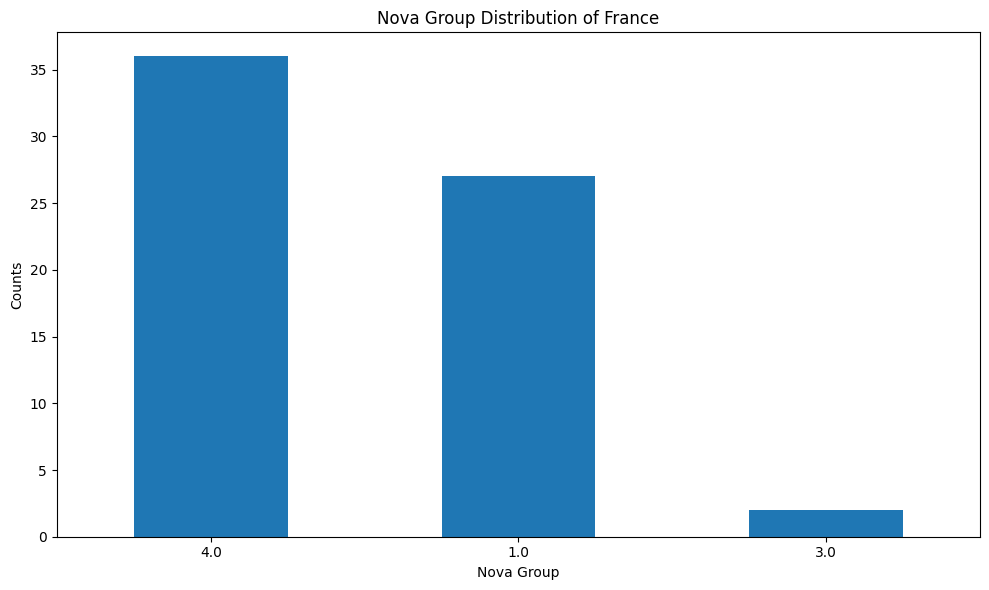

In [65]:
nvcounts = nvfrance.nova_group.value_counts()

plt.figure(figsize=(10,6))
nvcounts.plot(kind='bar')
plt.title('Nova Group Distribution of France')
plt.xlabel('Nova Group')
plt.ylabel('Counts')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

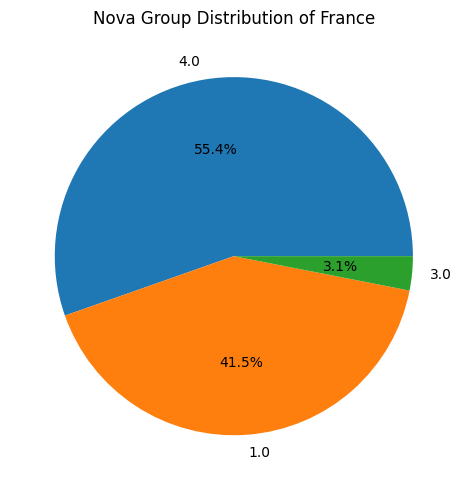

In [66]:
plt.figure(figsize=(5, 5))
nvcounts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Nova Group Distribution of France')
plt.ylabel('')
plt.tight_layout()
plt.show()

# BELGIUM

In [67]:
belgium = df[df['countries_tags'].str.contains('belgium')]
belgium

,code,product_name,brands,categories_tags,countries_tags,packaging_tags,stores,purchase_places,nutriscore_grade,nova_group,ecoscore_grade,ingredients_text,nutriments.sugars_100g,nutriments.energy-kcal_100g
29,42104773,Minute Maid Multivitamines,Minute Maid,"plant-based-foods-and-beverages, beverages, pl...","belgium, france, luxembourg","tetra-pak, tetra-brik-aseptic",Delhaize,unknown,e,4.0,unknown,eau; jus de fruits à base de concentré: orange...,NaN,NaN
32,54008304,Minute Maid Orange,Minute Maid,"beverages-and-beverages-preparations, plant-ba...","belgium, france",unknown,unknown,unknown,c,1.0,unknown,Jus d'orange 100%,NaN,NaN
33,5449000002860,Orange original minute maid,unknown,groceries,belgium,unknown,unknown,unknown,c,1.0,unknown,Orange concentré eau,NaN,NaN
35,5449000034274,Jus d'orange avec pulpe à base de concentré doux,Minute maid,"beverages-and-beverages-preparations, plant-ba...","belgium, france",tetra-brik,unknown,unknown,d,1.0,unknown,Jus d'orange avec pulpe à base de concentré,NaN,NaN
36,5449000045614,Minute Maid tropical,Minute Maid,"beverages-and-beverages-preparations, plant-ba...","belgium, france, martinique, switzerland","metal, can, drink-can",unknown,unknown,e,4.0,unknown,Eau ; jus de fruits à base de concentré (orang...,NaN,NaN
40,5449000098870,Minute Maid multivitamines,"Coca-Cola, Minute Maid","plant-based-foods-and-beverages, beverages, pl...","belgium, france","brick, cardboard",unknown,Belgium,e,4.0,unknown,"Eau, jus de fruits à base de concentré : orang...",NaN,NaN
41,5449000100573,Minute Maid multivitamines,Minute Maid,"beverages-and-beverages-preparations, plant-ba...","belgium, france",can,unknown,Belgium,e,4.0,unknown,eau; jus de fruits à base de concentré: orange...,NaN,NaN
42,5449000101068,Minute Maid Multivitamins Brik 20CL 4-pack,Minute Maid,unknown,"belgium, france, world",unknown,Delhaize,unknown,unknown,NaN,unknown,unknown,NaN,NaN
44,5449000111104,Great Start!,Minute Maid,"plant-based-foods-and-beverages, beverages, pl...","belgium, france","brick, cardboard",Noz,"Courrières,France",d,4.0,unknown,"Jus de fruits à base de concentré (orange 53%,...",NaN,NaN
67,5449000243416,Minute Maid Orange,Minute Maid,"plant-based-foods-and-beverages, beverages, pl...","belgium, france",brick,colruyt,unknown,c,1.0,unknown,JUS D'ORANGE À BASE DE CONCENTRé,NaN,NaN


In [68]:
pbelgium = belgium.copy()

# Packaging in Belgium
1) Cans are the most common packaging type — can appears 7 times (26.9%), making it the leading packaging format in Belgium.
2) Tetra-Pak and brick packaging are also highly used — both tetra-pak and brick appear 5 times each (19.2%). Together, they represent 10 out of 26 records (38.4%).
3) Packaging is relatively diverse — the dataset contains 8 packaging types. The top 3 categories (can, tetra-pak, brick) account for 17 of 26 records (65.4%), while the remaining 5 categories make up 34.6%.

In [69]:
pbelgium.packaging_tags.value_counts()


packaging_tags
unknown                          16
tetra-brik                        2
plastic, bottle                   2
brick, cardboard                  2
can, drink-can                    2
tetra-pak, tetra-brik-aseptic     1
metal, can, drink-can             1
can                               1
brique                            1
brick                             1
bottle                            1
tetra-pak, brick, gold-bricks     1
Name: count, dtype: int64

In [70]:
pbelgium = pbelgium[pbelgium.packaging_tags != 'unknown']
pbelgium.packaging_tags.value_counts()

packaging_tags
tetra-brik                       2
plastic, bottle                  2
brick, cardboard                 2
can, drink-can                   2
tetra-pak, tetra-brik-aseptic    1
metal, can, drink-can            1
can                              1
brique                           1
brick                            1
bottle                           1
tetra-pak, brick, gold-bricks    1
Name: count, dtype: int64

In [71]:
pbelgium['packaging_tags'] = pbelgium['packaging_tags'].str.split(',')
pbelgium = pbelgium.explode('packaging_tags')
pbelgium['packaging_tags'] = pbelgium['packaging_tags'].str.strip()
pbelgium.packaging_tags.value_counts()

packaging_tags
brick                 4
can                   4
bottle                3
drink-can             3
cardboard             2
plastic               2
tetra-brik            2
tetra-pak             2
metal                 1
tetra-brik-aseptic    1
brique                1
gold-bricks           1
Name: count, dtype: int64

In [72]:
tag_mapping = {
    # can
    'drink-can': 'can',

    # brick
    'brique': 'brick',

    # metal
    'aluminium': 'metal',

    # tetra-pak
    'tetra-brik': 'tetra-pak',
    'tetra-brik-aseptic': 'tetra-pak',
}

pbelgium['packaging_tags'] = pbelgium['packaging_tags'].replace(tag_mapping)

pbelgium.packaging_tags.value_counts()

packaging_tags
can            7
tetra-pak      5
brick          5
bottle         3
plastic        2
cardboard      2
metal          1
gold-bricks    1
Name: count, dtype: int64

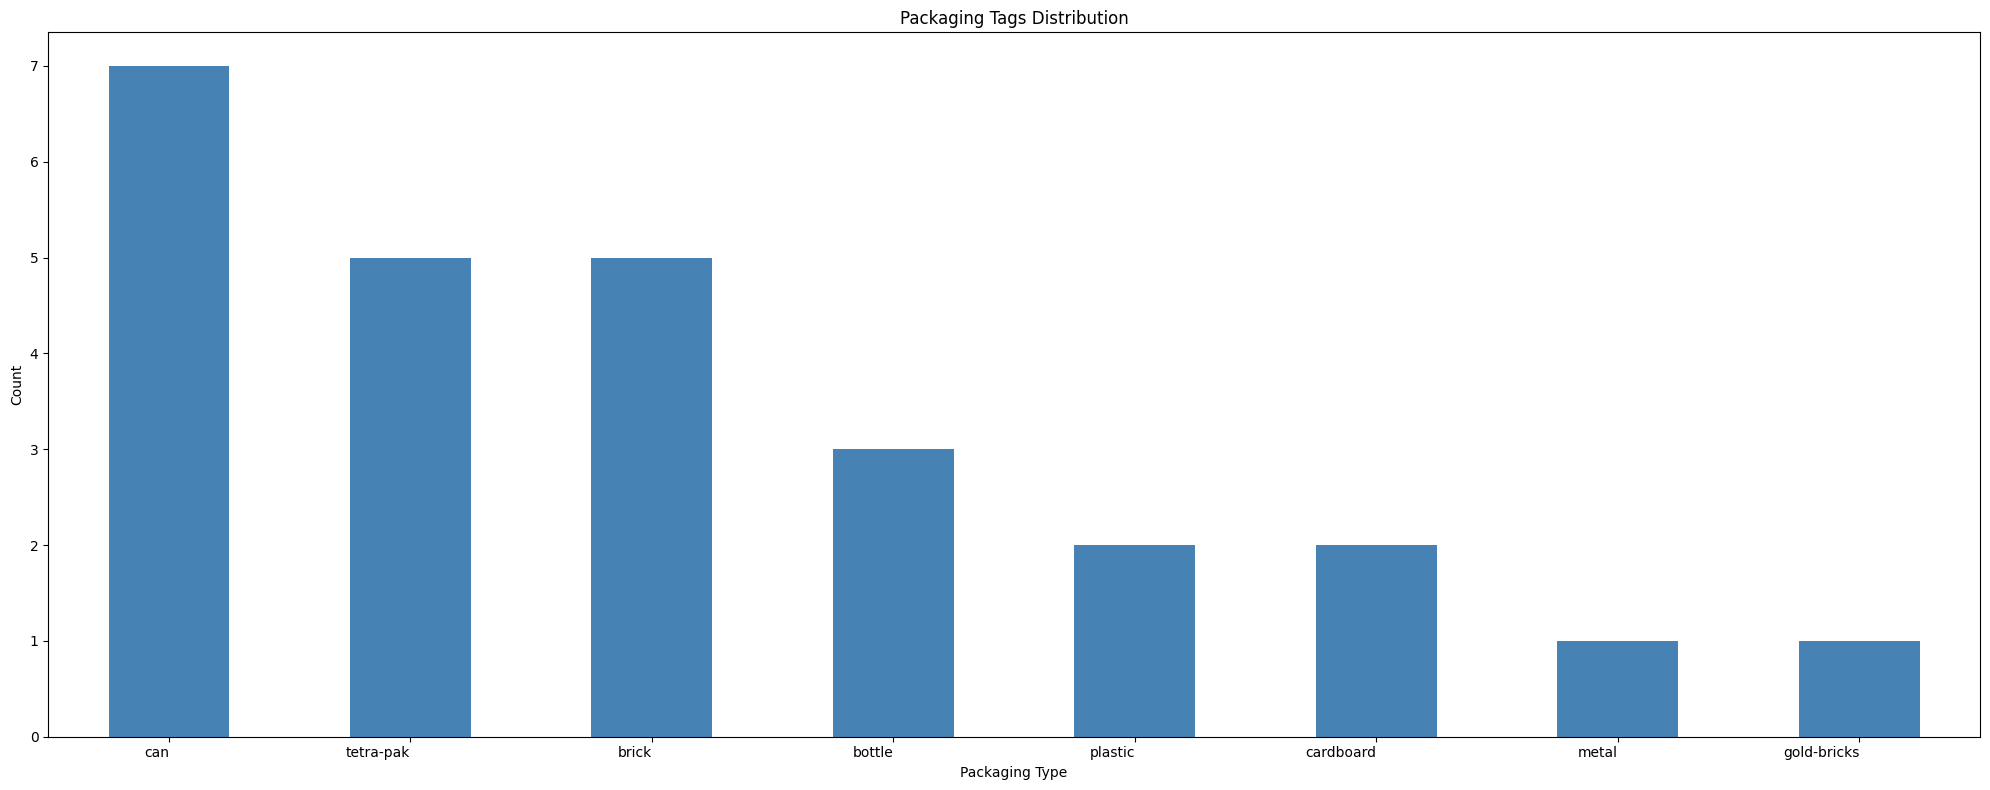

In [73]:
pcounts = pbelgium.packaging_tags.value_counts()

plt.figure(figsize=(20, 8))
pcounts.plot(kind='bar', color='steelblue')
plt.title('Packaging Tags Distribution')
plt.xlabel('Packaging Type')
plt.ylabel('Count')
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

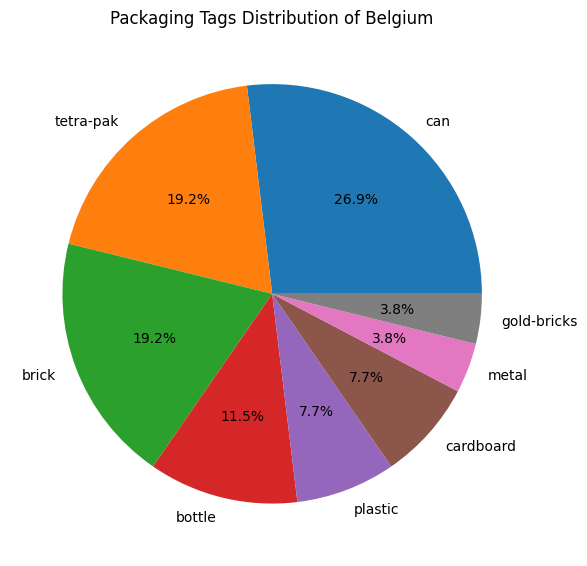

In [74]:
plt.figure(figsize=(6, 6))
pcounts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Packaging Tags Distribution of Belgium')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [75]:
nbelgium = belgium.copy()

# Belgium Nutriscore 
1) Grade C is the most common — 14 out of 26 products (53.8%) have a Nutri-Score C, meaning more than half of the analyzed products have an intermediate nutritional quality.
2) Lower nutritional scores are also significant — 8 products (30.8%) received Grade E, the lowest Nutri-Score category. Another 4 products (15.4%) received Grade D.
3) No products scored A or B — 100% of the 26 products fall into Grades C, D, or E, with 12 products (46.2%) receiving the lower D/E grades. This suggests the dataset contains relatively few products with strong nutritional profiles.

In [76]:
nbelgium.nutriscore_grade.value_counts()

nutriscore_grade
c          14
e           8
unknown     5
d           4
Name: count, dtype: int64

In [77]:
nbelgium = nbelgium[nbelgium['nutriscore_grade'] != 'unknown']
nbelgium.nutriscore_grade.value_counts()

nutriscore_grade
c    14
e     8
d     4
Name: count, dtype: int64

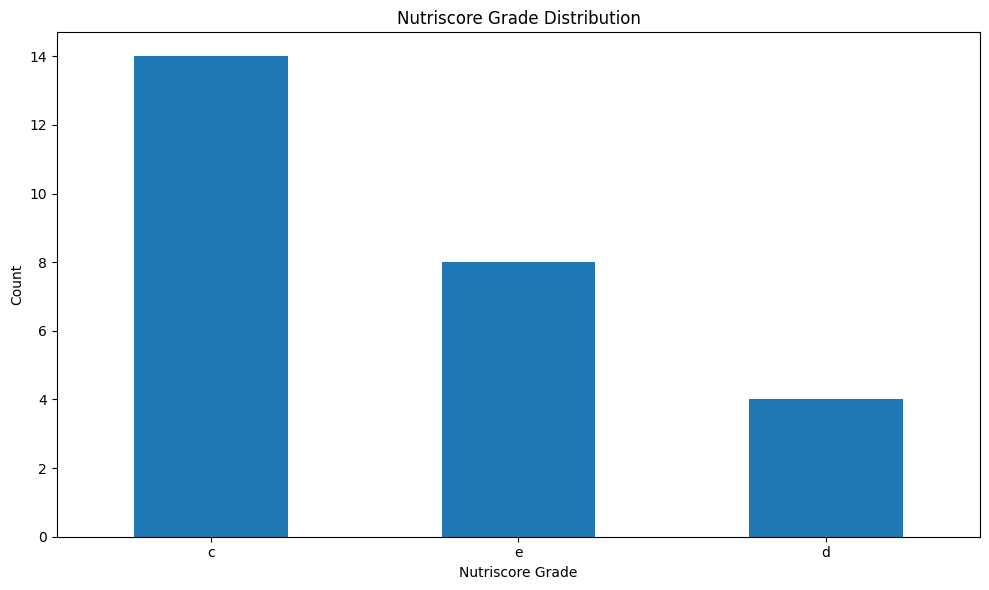

In [78]:
ncounts = nbelgium.nutriscore_grade.value_counts()

plt.figure(figsize=(10, 6))
ncounts.plot(kind='bar')
plt.title('Nutriscore Grade Distribution')
plt.xlabel('Nutriscore Grade')
plt.ylabel('Count')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

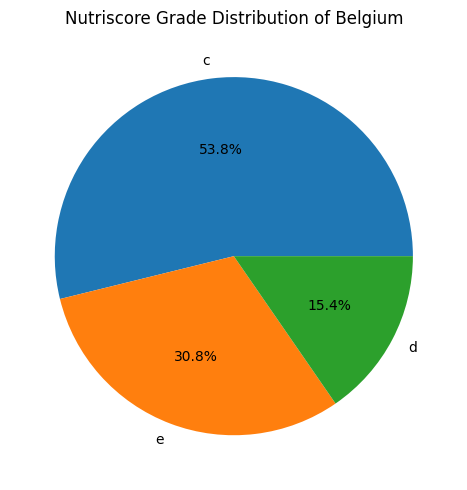

In [79]:
plt.figure(figsize=(5,5))
ncounts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Nutriscore Grade Distribution of Belgium')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [80]:
nvbelgium = belgium.copy()

# Belgium Nova Group
1) Equal split between minimally processed and ultra-processed foods — 8 out of 16 products (50%) are NOVA Group 4 (ultra-processed), while 8 products (50%) are NOVA Group 1 (unprocessed/minimally processed).
2) Ultra-processed foods form a significant share — 50% of the analyzed products belong to Group 4, meaning 1 in every 2 products is ultra-processed.
3) No Group 2 or Group 3 products are present — The dataset contains 0 products classified as Group 2 (processed culinary ingredients) or Group 3 (processed foods). This means the entire dataset is concentrated in Groups 1 and 4.

In [81]:
nvbelgium.nova_group.value_counts()

nova_group
4.0    8
1.0    8
Name: count, dtype: int64

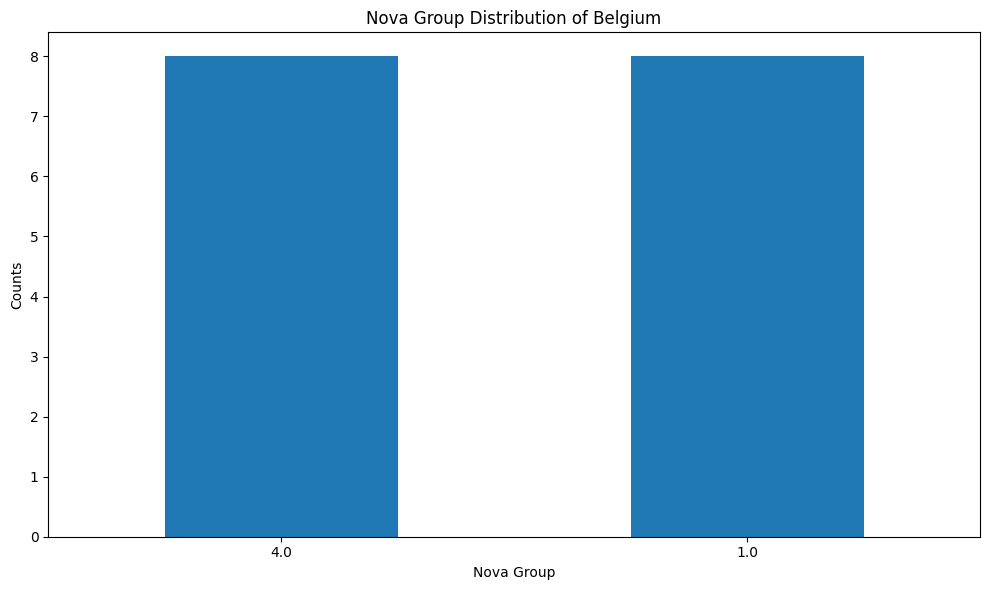

In [82]:
nvcounts = nvbelgium.nova_group.value_counts()

plt.figure(figsize=(10,6))
nvcounts.plot(kind='bar')
plt.title('Nova Group Distribution of Belgium')
plt.xlabel('Nova Group')
plt.ylabel('Counts')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

# SPAIN

In [83]:
spain = df[df['countries_tags'].str.contains("spain")]
spain

,code,product_name,brands,categories_tags,countries_tags,packaging_tags,stores,purchase_places,nutriscore_grade,nova_group,ecoscore_grade,ingredients_text,nutriments.sugars_100g,nutriments.energy-kcal_100g
39,5449000067357,Néctar de naranja,Minute Maid,"plant-based-foods-and-beverages, beverages, pl...","france, spain",unknown,unknown,unknown,e,NaN,unknown,unknown,NaN,NaN
51,5449000142573,Limon & nada,Minute Maid,"beverages-and-beverages-preparations, beverage...","france, spain",plastic,unknown,unknown,e,NaN,unknown,unknown,NaN,NaN
54,5449000156389,Duofrutas Tropical,Minute Maid,"plant-based-foods-and-beverages, beverages, pl...","france, spain",unknown,unknown,unknown,e,4.0,unknown,"Agua, azúcar, 10% leche desnatada, 10% zumo de...",NaN,NaN
65,5449000205261,Limón&nada ligero,Minute Maid,"beverages, carbonated-drinks, sodas, lemonade",spain,can,unknown,"Madrid,España",e,4.0,unknown,"Agua, zumo de limón a partir de concentrado (9...",NaN,NaN
82,87303483,Minute Maid Duo Tropical,Minute Maid,"plant-based-foods-and-beverages, beverages, pl...","france, spain",unknown,unknown,unknown,d,NaN,unknown,unknown,NaN,NaN
122,0025000030680,Mango Punch,Minute Maid,"beverages-and-beverages-preparations, plant-ba...","france, spain, united-states",unknown,unknown,unknown,e,4.0,unknown,"FILTERED WATER, HIGH FRUCTOSE CORN SYRUP, MANG...",NaN,NaN
126,90491979,Duo Mediterraneo,Minute Maid,"plant-based-foods-and-beverages, beverages, da...","france, spain",unknown,unknown,unknown,e,NaN,unknown,unknown,NaN,NaN
141,54492295,Duofrutas Mediterráneo,Minute Maid,unknown,spain,unknown,unknown,unknown,unknown,NaN,unknown,unknown,NaN,NaN
158,90061363,Antiox,Minute Maid,unknown,spain,unknown,unknown,unknown,unknown,NaN,unknown,unknown,NaN,NaN
250,5449000137159,unknown,Minute Maid,unknown,spain,unknown,unknown,unknown,unknown,NaN,unknown,unknown,NaN,NaN


In [84]:
pspain = spain.copy()

# Packaging Tags Distribution in Spain
1) Plastic and can packaging are equally represented, with 1 product each.
2) The dataset contains only 2 products with identified packaging tags, indicating very limited packaging data for this analysis.
3) Since the sample size is very small, no meaningful conclusion can be drawn about the preferred packaging type from this dataset alone.

In [85]:
pspain.packaging_tags.value_counts()

packaging_tags
unknown    11
plastic     1
can         1
Name: count, dtype: int64

In [86]:
pspain = pspain[pspain.packaging_tags != 'unknown']
pspain.packaging_tags.value_counts()

packaging_tags
plastic    1
can        1
Name: count, dtype: int64

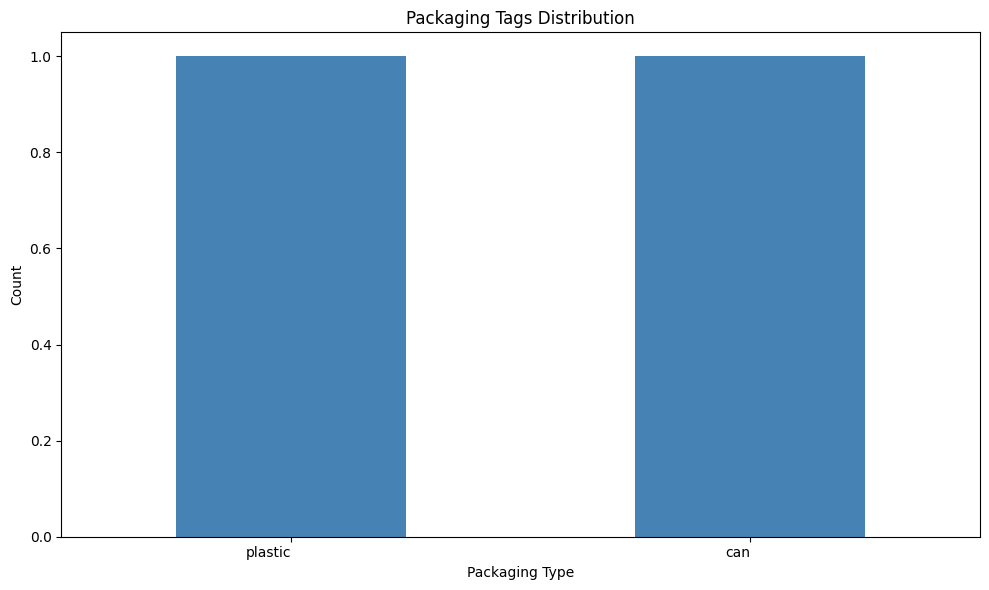

In [87]:
pcounts = pspain.packaging_tags.value_counts()

plt.figure(figsize=(10, 6))
pcounts.plot(kind='bar', color='steelblue')
plt.title('Packaging Tags Distribution')
plt.xlabel('Packaging Type')
plt.ylabel('Count')
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

# Nutriscore Grade Distribution in Spain
1) Grade E dominates, with 6 products, indicating that most of the analyzed products have a relatively poor nutritional profile.
2) Grade D has 2 products, showing limited representation of products with moderately poor nutritional quality.
3) Grade B has only 1 product, while no products received Grade A or C, indicating that healthier products are underrepresented in this dataset.

In [88]:
nspain = spain.copy()

In [89]:
nspain.nutriscore_grade.value_counts()

nutriscore_grade
e          6
unknown    4
d          2
b          1
Name: count, dtype: int64

In [90]:
nspain = nspain[nspain.nutriscore_grade != 'unknown']
nspain.nutriscore_grade.value_counts()

nutriscore_grade
e    6
d    2
b    1
Name: count, dtype: int64

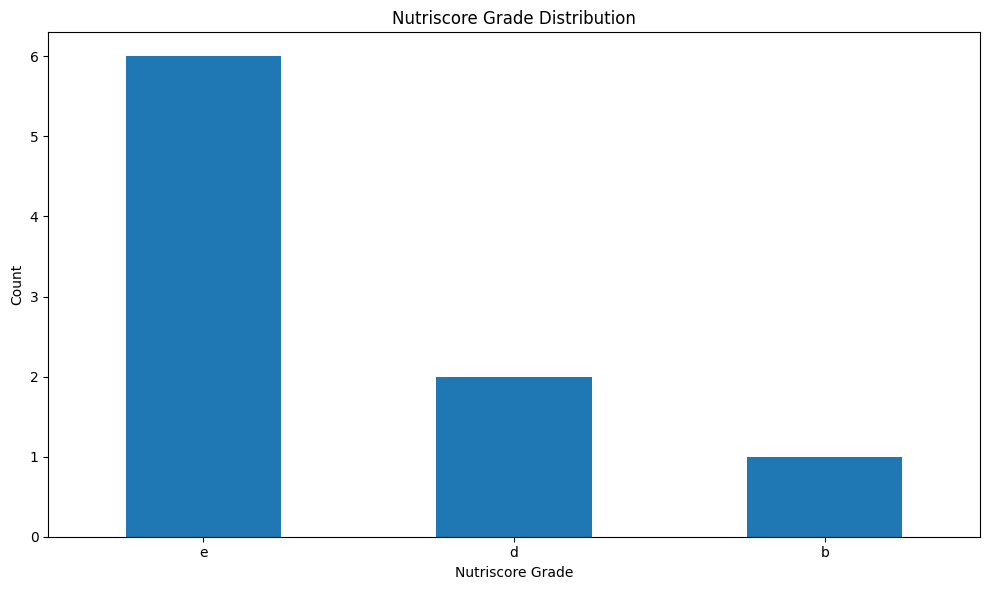

In [91]:
ncounts = nspain.nutriscore_grade.value_counts()

plt.figure(figsize=(10, 6))
ncounts.plot(kind='bar')
plt.title('Nutriscore Grade Distribution')
plt.xlabel('Nutriscore Grade')
plt.ylabel('Count')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

# Nova Group Distribution in Spain

In [92]:
nvspain = spain.copy()

In [93]:
nvspain.nova_group.value_counts()

nova_group
4.0    3
Name: count, dtype: int64

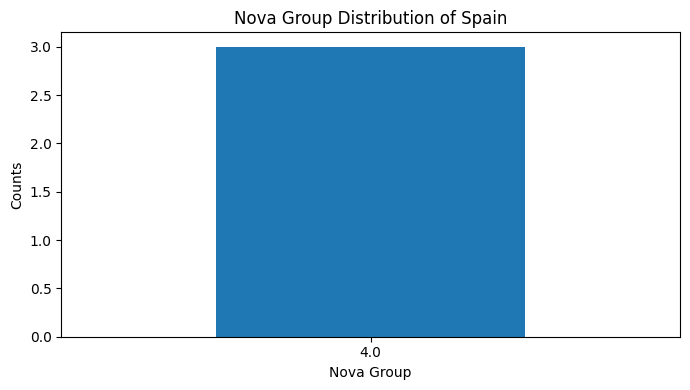

In [102]:
nvcounts = nvspain.nova_group.value_counts()

plt.figure(figsize=(7,4))
nvcounts.plot(kind='bar')
plt.title('Nova Group Distribution of Spain')
plt.xlabel('Nova Group')
plt.ylabel('Counts')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

# Here are Overall Minute Maid Insights from this file and another file


# Packaging 
1. Metadata Completeness Gap: The USA dataset has 97.2% unknown packaging tags, and Canada has 91.2% unknown, while Belgium (51.6% unknown) and France (73.7% unknown) have much higher tag completeness.
2. Packaging Distribution: Where tags are present, France and Belgium are dominated by aluminum cans (26.9% to 37.0%) and bottles, whereas Canada relies heavily on Tetra-Pak cartons and multilayer composites.
# Nutriscore Grade
1. Dominance of Poor Nutritional Scores: Canada (56.2%) and France (45.1%) have their largest single segment concentrated in Grade E (the lowest nutritional score).
2. Polarized Profile in USA: Shows a split distribution with 38.5% at Grade B and 36.1% at Grade E, with very few intermediate items in Grade D (5.7%).
3. Belgium’s Mid-Tier Concentration: Centered heavily at Grade C (53.8%), followed by Grade E (30.8%), with 0.0% recorded in top tiers (Grade A/B).
# Nova Group
1. USA leads in Ultra-Processed Foods: 81.6% of USA evaluated products belong to NOVA Group 4.0, followed by Canada at 65.0%.
2. Europe emphasizes Whole Foods: Belgium reaches 50.0% and France 41.5% in NOVA Group 1.0 (unprocessed or minimally processed foods).
3. Intermediate Processing (NOVA 3.0): Present in minimal proportions across all countries (Canada at 5.0%, France at 3.1%, and 0.0% recorded for USA and Belgium).

